<a href="https://colab.research.google.com/github/SchwartzNU/DJ_schwartzlab/blob/master/Copy_of_TS2Vec_model_analysis_Greg_Jul2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
result_types = unpickle('/content/drive/MyDrive/models_crop_fish/newRGC_withnamesandcurrent.pkl')
selected_labels = [3, 6, 20, 26, 14, 12, 13, 31, 27, 29]
label_map = {label: idx for idx, label in enumerate(selected_labels)}

/tmp/ipykernel_6904/2033791891.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dict = pickle.load(f, encoding='bytes')


In [ ]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
    return dict

We hold off half of the dataset for training the embedding, and half for testing the linear decoder

In [ ]:
import numpy as np
import pandas as pd
def split_train_test(CWTdata, ctype, currents, label_map):
    tmpdata = CWTdata[ctype]
    allnames = [tmpdata[i][1] for i in range(len(tmpdata))]
    unique_names, counts = np.unique(allnames, return_counts=True)
    print(unique_names)
    print(counts)
    testn = 0
    testn = np.floor(len(unique_names)/2) #hold out half for testing
    testn = int(testn)
    test_array = np.random.choice(range(len(unique_names)), testn, replace=False) #cellid for hold out testing
    print(test_array)
    train_array = np.setdiff1d(np.arange(len(unique_names)), test_array)
    print(train_array)

    #now go back to single traces
    test_trace = []
    test_names = {}
    test_names[label_map[ctype]]=[]
    cellname_test = []
    cellid_test = [] #note: this is cell idx in the test_trace (from unique names)
    for i in test_array:
        testname = unique_names[i]
        cellname_test.append(testname)
        test_names[label_map[ctype]].append(testname)
        idx = [j for j, x in enumerate(allnames) if x == testname]
        for ni in idx:

            if np.abs(tmpdata[ni][2])>currents and tmpdata[ni][0].shape[1] == 1000:
               test_trace.append(ni)
               cellid_test.append(i)
            #elif tmpdata[ni][0].shape[1] != 1000:
            #   print(tmpdata[ni][0].shape)
               #print(tmpdata[ni][0].shape)

    print(len(test_trace))

    train_trace = []
    train_names = {}
    train_names[label_map[ctype]]=[]
    for i in train_array:
        trainname = unique_names[i]
        train_names[label_map[ctype]].append(trainname)
        idx = [j for j, x in enumerate(allnames) if x == trainname]
        for ni in idx:
            if np.abs(tmpdata[ni][2])>currents and tmpdata[ni][0].shape[1] == 1000:
               train_trace.append(ni)
            #elif tmpdata[ni][0].shape[1] != 1000:
            #   print(tmpdata[ni][0].shape)


    print(len(train_trace))
    print(np.intersect1d(np.asarray(train_trace), np.asarray(test_trace)))
    return train_trace, test_trace, train_names, test_names, cellid_test, cellname_test

In [ ]:
train_data = []
test_data = []
train_labels = []
test_labels = []
all_trainnames = {}
all_testnames ={}
test_cellid = []
test_cellnames =[]
for key in result_types.keys():
    tmp_train, tmp_test, tmptrainnames, tmptestnames, cellid_all, cellname_alltest = split_train_test(result_types,key, 150, label_map)
    all_trainnames[label_map[key]] = tmptrainnames
    all_testnames[label_map[key]] = tmptestnames
    tmplist1 = [result_types[key][i][0].T for i in tmp_train]
    tmplabel1 = np.ones(len(tmp_train))*label_map[key]

    train_data +=tmplist1
    train_labels +=list(tmplabel1)

    tmplist2 = [result_types[key][i][0].T for i in tmp_test]
    tmplabel2 = np.ones(len(tmp_test))*label_map[key]

    test_data +=tmplist2
    test_labels +=list(tmplabel2)
    test_cellid += cellid_all
    test_cellnames +=cellname_alltest
    print('the key that added is ')
    print(label_map[key])
    print(np.unique(np.asarray(test_labels)))
    if label_map[key] ==9:
       print('last class')
       print(len(tmplist2))
       print(tmplabel2)

train_data = np.asarray(train_data)
test_data = np.asarray(test_data)
train_labels = np.asarray(train_labels)
test_labels = np.asarray(test_labels)
test_cellid = np.asarray(test_cellid)

['Cell_10181.mat' 'Cell_10877.mat' 'Cell_6899.mat' 'Cell_6902.mat'
 'Cell_6910.mat' 'Cell_6911.mat' 'Cell_6923.mat' 'Cell_6955.mat'
 'Cell_9763.mat']
[60 90 60 60 60 60 60 71 50]
[5 8 2 6]
[0 1 3 4 7]
90
83
[]
the key that added is 
0
[0.]
['Cell_10240.mat' 'Cell_11193.mat' 'Cell_5226.mat' 'Cell_6914.mat'
 'Cell_6915.mat' 'Cell_6916.mat']
[ 90  90 100  60  60  60]
[0 4 3]
[1 2 5]
32
83
[]
the key that added is 
1
[0. 1.]
['Cell_10428.mat' 'Cell_10591.mat' 'Cell_10619.mat' 'Cell_10684.mat'
 'Cell_10699.mat' 'Cell_10735.mat' 'Cell_10837.mat' 'Cell_10999.mat'
 'Cell_11008.mat' 'Cell_11199.mat' 'Cell_11304.mat' 'Cell_11312.mat'
 'Cell_162.mat' 'Cell_176.mat' 'Cell_210.mat' 'Cell_2170.mat'
 'Cell_2171.mat' 'Cell_2730.mat' 'Cell_7036.mat' 'Cell_9160.mat'
 'Cell_9292.mat' 'Cell_9337.mat' 'Cell_9368.mat' 'Cell_9369.mat'
 'Cell_9387.mat' 'Cell_9779.mat']
[ 33  90  60  60  60  60  90  90  90  90  90  90  60  60  60 100  70  60
  90  90  90  90  90  90  90 118]
[11  6  7 21 24 18 15  4  1 12 10  

In [ ]:
!git clone https://github.com/zhihanyue/ts2vec
import os
os.chdir('ts2vec')

Cloning into 'ts2vec'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 133 (delta 23), reused 21 (delta 21), pack-reused 94 (from 1)
Receiving objects: 100% (133/133), 37.01 KiB | 3.70 MiB/s, done.
Resolving deltas: 100% (67/67), done.


The training loop

In [ ]:
from ts2vec import TS2Vec
#default parameters for TS2Vec (from their github)
model2 = TS2Vec(
    input_dims=315,
    output_dims=320,
    batch_size=128
)
loss_log = model2.fit(
    train_data,
    n_epochs = 30,
    verbose=True
)

Epoch #0: loss=30.074315600925022
Epoch #1: loss=5.617299715677897
Epoch #2: loss=4.468778795666164
Epoch #3: loss=4.026445494757758
Epoch #4: loss=4.0549534691704645
Epoch #5: loss=3.935373968548245
Epoch #6: loss=3.767164945602417
Epoch #7: loss=3.7677619457244873
Epoch #8: loss=3.6483663982815213
Epoch #9: loss=3.7191363440619574
Epoch #10: loss=3.577961868709988
Epoch #11: loss=3.462259716457791
Epoch #12: loss=3.360600153605143
Epoch #13: loss=3.2201481925116644
Epoch #14: loss=3.120455609427558
Epoch #15: loss=3.0748401747809515
Epoch #16: loss=3.0092931853400335
Epoch #17: loss=3.010710848702325
Epoch #18: loss=2.7993654939863415
Epoch #19: loss=2.6866471502516003
Epoch #20: loss=2.59144393603007
Epoch #21: loss=2.484655830595228
Epoch #22: loss=2.429347965452406
Epoch #23: loss=2.299254881011115
Epoch #24: loss=2.3661019139819675
Epoch #25: loss=2.111913389629788
Epoch #26: loss=2.3741319444444446
Epoch #27: loss=2.2934266328811646
Epoch #28: loss=1.9512901968426175
Epoch #29: 

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from utils import init_dl_program, name_with_datetime, pkl_save, data_dropout
from sklearn.neighbors import NearestNeighbors

#k-NN graph on labels only
def purity_baseline(y):
    """
    Expected same-label rate for a random neighbor, excluding self.
    """
    y = np.asarray(y)
    n = len(y)
    vals = []
    for yi in y:
        vals.append((np.sum(y == yi) - 1) / (n - 1))
    return np.mean(vals)

#baseline level of chance
def chance_balanced_accuracy(y):
    return 1.0 / len(np.unique(y))

def knn_indices(X, k=10, metric="cosine"):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric).fit(X)
    inds = nbrs.kneighbors(X, return_distance=False)
    return inds[:, 1:]  # remove self

def knn_purity(X, y, k=10, metric="cosine"):
    y = np.asarray(y)
    nn = knn_indices(X, k=k, metric=metric)
    purity_i = (y[nn] == y[:, None]).mean(axis=1)
    return purity_i.mean()

def knn_agreement(X1, X2, k=10, metric="cosine"):
    nn1 = knn_indices(X1, k=k, metric=metric)
    nn2 = knn_indices(X2, k=k, metric=metric)

    vals = []
    for a, b in zip(nn1, nn2):
        vals.append(len(set(a).intersection(set(b))) / k)
    return np.mean(vals)

def same_label_knn_recovery(X_ref, X_test, y, k=10, metric="cosine"):
    """
    X_ref:  full_series representation
    X_test: a_i representation

    Measures: among same-label neighbors found by full_series,
    how many are recovered by a_i?
    """
    y = np.asarray(y)
    nn_ref = knn_indices(X_ref, k=k, metric=metric)
    nn_test = knn_indices(X_test, k=k, metric=metric)

    vals = []
    for i in range(len(y)):
        ref_same = {j for j in nn_ref[i] if y[j] == y[i]}
        test_set = set(nn_test[i])

        if len(ref_same) == 0:
            continue

        vals.append(len(ref_same.intersection(test_set)) / len(ref_same))

    return np.mean(vals) if vals else np.nan


def centered_kernel(X):
    """
    Linear kernel with row/column centering.
    X: (N, F)
    """
    K = X @ X.T
    H = np.eye(K.shape[0]) - np.ones_like(K) / K.shape[0]
    return H @ K @ H

def offdiag(K):
    idx = np.triu_indices(K.shape[0], k=1)
    return K[idx]

#this is to compare mean pooling vs. max pooling
def compare_instance_vs_full(z, phi_full, normalize_readouts=False):
    """
    z:        (N, T, F), unpooled latent sequence
    phi_full: (N, F), official model.encode(..., encoding_window='full_series')

    Compares geometry of:
        a_i = mean_t z_i(t)
    against:
        phi_full
    """
    a = z.mean(axis=1)

    if normalize_readouts:
        a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
        phi_full = phi_full / (np.linalg.norm(phi_full, axis=1, keepdims=True) + 1e-8)

    K_a = centered_kernel(a)
    K_full = centered_kernel(phi_full)

    va = offdiag(K_a)
    vf = offdiag(K_full)

    corr = np.corrcoef(va, vf)[0, 1]

    # Best scale alignment: minimize ||K_full - c K_a||
    c = np.sum(K_full * K_a) / (np.sum(K_a * K_a) + 1e-12)
    rel_resid = np.linalg.norm(K_full - c * K_a) / (np.linalg.norm(K_full) + 1e-12)

    return {
        "corr_offdiag": corr,
        "best_scale": c,
        "relative_residual_after_scaling": rel_resid,
    }


def center_kernel(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def kernel_alignment(K1, K2, eps=1e-12):
    K1c = center_kernel(K1)
    K2c = center_kernel(K2)
    return np.sum(K1c * K2c) / (
        np.linalg.norm(K1c) * np.linalg.norm(K2c) + eps
    )

def label_kernel(y):
    y = np.asarray(y)
    return (y[:, None] == y[None, :]).astype(float)

def geometry_label_alignment(X, y, normalize=True):
    X = np.asarray(X)
    if normalize:
        X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

    K = X @ X.T
    Ky = label_kernel(y)

    return kernel_alignment(K, Ky)

# z: (N, T, F)
# phi_full: model.encode(data, encoding_window="full_series")

def instance_component_train_test(z_train, z_test):
    """
    a_i(k) = mean_t z_i(t,k) - global_train_mean(k)

    The centering constant does not matter much for logistic regression
    with intercept, but using train mean avoids test leakage.
    """
    mu = z_train.mean(axis=(0, 1))          # (F,)
    a_train = z_train.mean(axis=1) - mu     # (N_train, F)
    a_test = z_test.mean(axis=1) - mu       # (N_test, F)
    return a_train, a_test

#sample weights are determined by how frequent we sample a particular class
def fit_linear_probe_weights(X_train, y_train, X_test, y_test, s_weights):
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            class_weight=None,
            solver="lbfgs"
        )
    )
    clf.fit(X_train, y_train, logisticregression__sample_weight=s_weights)
    pred = clf.predict(X_test)

    return {
        "clf": clf,
        "pred": pred,
        "acc": accuracy_score(y_test, pred),
        "bal_acc": balanced_accuracy_score(y_test, pred),
    }

#ANOVA decomposition of alpha(i,j)+beta(t, t') +gamma(i,j,t,t')
def eta_gamma_fast(z, eps=1e-12):
    """
    Computes eta^2_gamma without explicitly forming M or gamma.

    z: shape (N, T, F)

    Returns:
        eta2_gamma
        alpha
        beta
        stats dict
    """
    z = np.asarray(z, dtype=np.float64)
    N, T, F = z.shape

    # Grand mean of embeddings
    z_bar = z.mean(axis=(0, 1))          # shape (F,)
    mu = float(z_bar @ z_bar)           # grand mean of M

    # Instance means: u_i
    u = z.mean(axis=1)                  # shape (N, F)
    alpha = u @ u.T - mu                # shape (N, N)

    # Time means: v_t
    v = z.mean(axis=0)                  # shape (T, F)
    beta = v @ v.T - mu                 # shape (T, T)

    # Total centered sum of squares of M:
    # ||X X^T||_F^2 - (NT)^2 * mu^2
    X = z.reshape(N * T, F)
    XtX = X.T @ X
    ss_M = np.sum(XtX ** 2)
    ss_total = ss_M - (N * T) ** 2 * mu ** 2

    # Contributions of alpha and beta in full M space
    ss_alpha = T ** 2 * np.sum(alpha ** 2)
    ss_beta = N ** 2 * np.sum(beta ** 2)

    # Orthogonal residual
    ss_gamma = ss_total - ss_alpha - ss_beta
    ss_gamma = max(ss_gamma, 0.0)  # numerical guard

    eta2_gamma = ss_gamma / (ss_total + eps)

    stats = {
        "mu": mu,
        "ss_total": ss_total,
        "ss_alpha": ss_alpha,
        "ss_beta": ss_beta,
        "ss_gamma": ss_gamma,
        "eta2_alpha": ss_alpha / (ss_total + eps),
        "eta2_beta": ss_beta / (ss_total + eps),
        "eta2_gamma": eta2_gamma,
    }

    return eta2_gamma, alpha, beta, stats

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


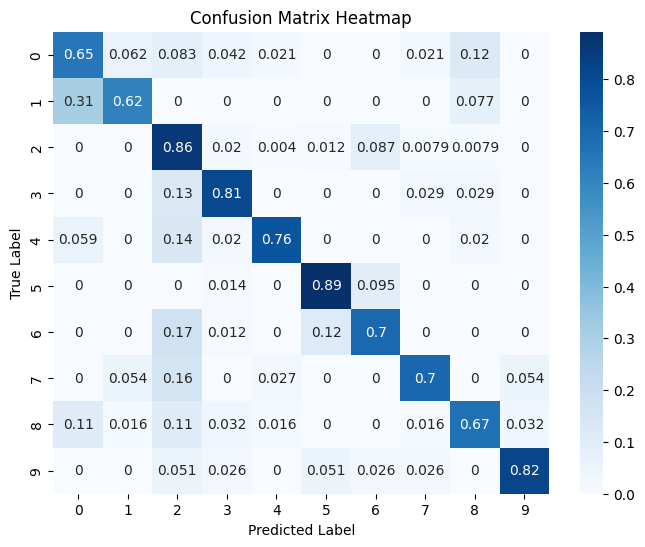

0.7882513661202186

In [ ]:
import numpy as np
from tasks import _eval_protocols as eval_protocols
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nidx = np.random.permutation(test_data.shape[0])
shuffle_labels = test_labels[nidx]
shuffled_testdata = test_data[nidx,:,:]
shuffled_cellid = test_cellid[nidx]

train_repr1 = model2.encode(shuffled_testdata[0:600,::], encoding_window='full_series' )
test_repr1 = model2.encode(shuffled_testdata[600::,::], encoding_window='full_series')
fit_clf = eval_protocols.fit_lr
clf = fit_clf(train_repr1, shuffle_labels[0:600])
y_pred = clf.predict(test_repr1)
y_true = shuffle_labels[600::]
cm = confusion_matrix(shuffle_labels[600::], y_pred, normalize='true')
class_labels = np.unique(shuffle_labels[600::])
df_cm = pd.DataFrame(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
clf.score(test_repr1, shuffle_labels[600::])

In [ ]:
def type_cell_trace_weights(y, cell_ids):
    """
    Each label gets equal total weight.
    Within each label, each cell gets equal weight.
    Within each cell, traces share that cell's weight.

    y:        trace labels, shape (N,)
    cell_ids: cell id for each trace, shape (N,)
    """
    y = np.asarray(y).ravel()
    cell_ids = np.asarray(cell_ids).ravel()

    w = np.zeros(len(y), dtype=float)

    for lab in np.unique(y):
        label_mask = y == lab
        cells = np.unique(cell_ids[label_mask])

        for c in cells:
            idx = label_mask & (cell_ids == c)
            w[idx] = 1.0 / (len(cells) * idx.sum())

    # normalize for numerical convenience
    w *= len(w) / w.sum()
    return w

weights = type_cell_trace_weights(shuffle_labels, shuffled_cellid)

In [ ]:
z_train = model2.encode(shuffled_testdata[0:600,::], encoding_window=None)          # (N_train, T, F)
z_test  = model2.encode(shuffled_testdata[600::,::],  encoding_window=None)
a_train, a_test = instance_component_train_test(z_train, z_test)
phi_train = model2.encode(shuffled_testdata[0:600,::], encoding_window='full_series')
phi_test  = model2.encode(shuffled_testdata[600::,::],  encoding_window='full_series')
res_phi = fit_linear_probe_weights(phi_train, shuffle_labels[0:600], phi_test, shuffle_labels[600::], weights[0:600])
res_a   = fit_linear_probe_weights(a_train,   shuffle_labels[0:600], a_test,   shuffle_labels[600::], weights[0:600])

In [ ]:
rows = []
agreement = np.mean(res_phi["pred"] == res_a["pred"])
eta2_fast, alpha_fast, beta_fast, eta_stats = eta_gamma_fast(z_train)
gram_stats = compare_instance_vs_full(z_train, phi_train, normalize_readouts=False)
a = z_train.mean(axis=1)
align_a = geometry_label_alignment(a, shuffle_labels[0:600])
align_full = geometry_label_alignment(phi_train, shuffle_labels[0:600])
purity_a = knn_purity(a, shuffle_labels[0:600], k=10)
purity_full = knn_purity(phi_train, shuffle_labels[0:600], k=10)

y_test = np.asarray(shuffle_labels[600::]).ravel()
pred_phi = np.asarray(res_phi["pred"]).ravel()
pred_a = np.asarray(res_a["pred"]).ravel()

full_correct = pred_phi == y_test
a_correct = pred_a == y_test

In [ ]:
cell_table = per_cell_accuracy_table(
    y_true=np.asarray(shuffle_labels[600::]).ravel(),
    pred_full=res_phi["pred"],
    pred_a=res_a["pred"],
    cell_ids=np.asarray(shuffled_cellid[600::]).ravel()
)
cell_table

NameError: name 'per_cell_accuracy_table' is not defined